# 04 — Model Evaluation

Generates all plots and metrics needed for the presentation.

## Class concepts verified here
| Plot | Class concept |
|---|---|
| RMSE / MAE | Block 1: loss functions and evaluation metrics |
| NASA Score | Domain-specific asymmetric loss |
| Predicted vs Actual scatter | Generalization — Block 1 |
| Residuals distribution | Overfitting check — Block 1 |
| Attention weight heatmap | Attention mechanism — Block 1/4 |
| Feature importance | Gradient-based — Block 2 (gradient flow) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

plt.style.use('dark_background')
PROC_DIR  = Path('../data/processed')
MODEL_DIR = Path('../backend/model')

CYAN  = '#00d4ff'
AMBER = '#f59e0b'
NAVY  = '#0a0f1e'
GREEN = '#10b981'
RED   = '#ef4444'

In [2]:
# ── Reload model — DotProductAttention must be redefined ─────────────────
class DotProductAttention(layers.Layer):
    """Self-attention over time dimension (Block 1/4 — attention mechanism)."""
    def call(self, x):
        d = tf.cast(tf.shape(x)[-1], tf.float32)
        score    = tf.matmul(x, x, transpose_b=True) / tf.math.sqrt(d)
        weights  = tf.nn.softmax(score, axis=-1)
        attended = tf.matmul(weights, x)
        return attended, weights

model = keras.models.load_model(
    MODEL_DIR / 'lstm_model.keras',
    custom_objects={'DotProductAttention': DotProductAttention}
)

X_test = np.load(PROC_DIR / 'X_test.npy')
y_test = np.load(PROC_DIR / 'y_test.npy')
meta   = joblib.load(MODEL_DIR / 'scaler.pkl')
FEATURE_COLS = meta['feature_cols']

y_pred = model.predict(X_test, batch_size=128, verbose=0).flatten()
print(f'Test samples: {len(y_pred)}')

/opt/anaconda3/envs/dl_project/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Test samples: 100


W0000 00:00:1781036458.085544       1 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" model: "0" frequency: 2400 num_cores: 10 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


## Evaluation Metrics

**RMSE** — Block 1 standard regression metric: `sqrt(mean((ŷ - y)²))`  
**MAE** — mean absolute error, more interpretable (in cycles)  
**NASA Score** — asymmetric: late predictions penalized 10× harder than early ones.  
  If d = pred - true: `exp(-d/13) - 1` for d<0 (early), `exp(d/10) - 1` for d≥0 (late)  
  Engineering rationale: sending a plane for maintenance 10 cycles too early costs money; 
  sending it 10 cycles too late risks catastrophic failure.

In [3]:
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

rmse  = float(np.sqrt(np.mean((y_pred - y_test) ** 2)))
mae   = float(np.mean(np.abs(y_pred - y_test)))
score = nasa_score(y_test, y_pred)

pct_within_10 = float(np.mean(np.abs(y_pred - y_test) <= 10) * 100)
pct_within_25 = float(np.mean(np.abs(y_pred - y_test) <= 25) * 100)

print('━' * 45)
print(f'  RMSE:              {rmse:.2f} cycles')
print(f'  MAE:               {mae:.2f} cycles')
print(f'  NASA Score:        {score:.1f}  (lower = better)')
print(f'  Within ±10 cycles: {pct_within_10:.1f}%')
print(f'  Within ±25 cycles: {pct_within_25:.1f}%')
print('━' * 45)
print('FD001 literature benchmark: RMSE ≈ 12–18, NASA Score < 300')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RMSE:              14.52 cycles
  MAE:               10.33 cycles
  NASA Score:        603.4  (lower = better)
  Within ±10 cycles: 59.0%
  Within ±25 cycles: 92.0%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
FD001 literature benchmark: RMSE ≈ 12–18, NASA Score < 300


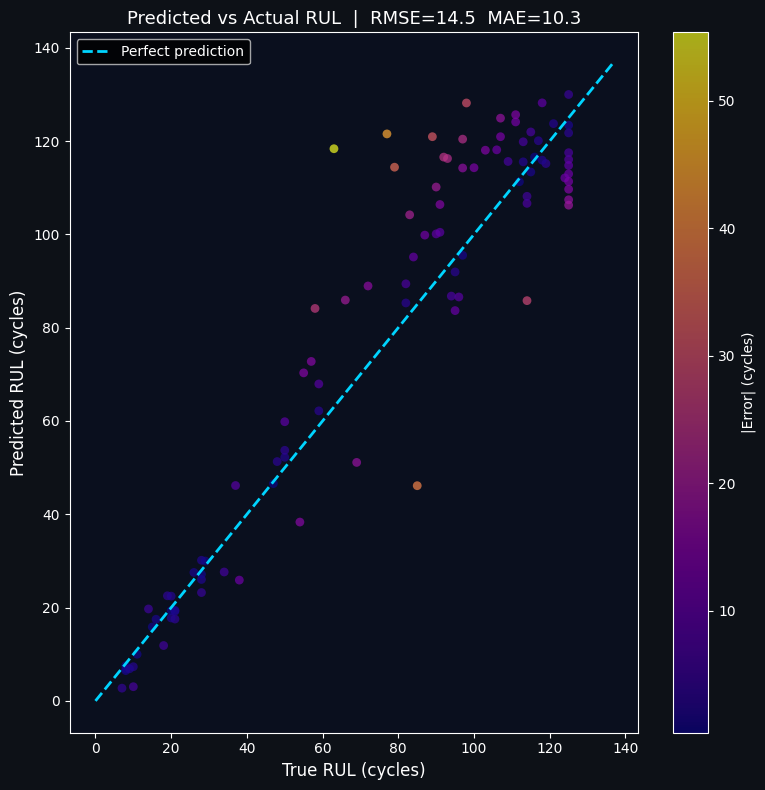

In [4]:
# ── Plot 1: Predicted vs Actual scatter ────────────────────────────────────
# Block 1: generalization check — if model memorized, all points would be on y-axis
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(y_test, y_pred,
                     c=np.abs(y_pred - y_test), cmap='plasma',
                     alpha=0.7, s=40, edgecolors='none')
lim = max(y_test.max(), y_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color=CYAN, linewidth=2, label='Perfect prediction')
plt.colorbar(scatter, ax=ax, label='|Error| (cycles)')
ax.set_xlabel('True RUL (cycles)', fontsize=12)
ax.set_ylabel('Predicted RUL (cycles)', fontsize=12)
ax.set_title(f'Predicted vs Actual RUL  |  RMSE={rmse:.1f}  MAE={mae:.1f}', fontsize=13)
ax.legend()
ax.set_facecolor(NAVY)
fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.savefig(PROC_DIR / 'pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

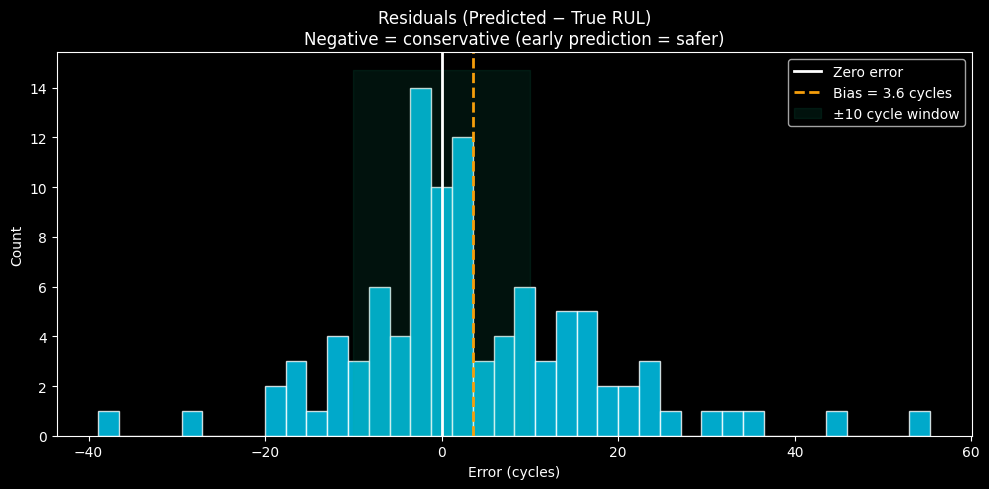

In [5]:
# ── Plot 2: Residuals distribution ─────────────────────────────────────────
# Block 1: zero-mean residuals = unbiased model. Skew toward negative = conservative
residuals = y_pred - y_test
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuals, bins=40, color=CYAN, edgecolor='white', alpha=0.8)
ax.axvline(0, color='white', linewidth=2, label='Zero error')
ax.axvline(residuals.mean(), color=AMBER, linewidth=2, linestyle='--',
           label=f'Bias = {residuals.mean():.1f} cycles')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 100],
                  -10, 10, alpha=0.1, color=GREEN, label='±10 cycle window')
ax.set_title('Residuals (Predicted − True RUL)\nNegative = conservative (early prediction = safer)', fontsize=12)
ax.set_xlabel('Error (cycles)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(PROC_DIR / 'residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## Attention Weight Visualization

**Block 1 / 4 — Attention mechanism:** The attention layer produces a weight matrix of shape [30, 30] — how much each of the 30 timesteps attends to every other timestep. We collapse it to [30] by averaging across the attended dimension to get "how much does each cycle contribute?"

**Expected pattern:** The model should assign higher weights to the **most recent cycles** (rightmost in the sequence) because they reflect the current degradation state — the most predictive signal for remaining life.

W0000 00:00:1781036459.146648       1 op_level_cost_estimator.cc:699] Error in PredictCost() for the op: op: "Softmax" attr { key: "T" value { type: DT_FLOAT } } attr { key: "_has_manual_control_dependencies" value { b: true } } inputs { dtype: DT_FLOAT shape { unknown_rank: true } } device { type: "CPU" model: "0" frequency: 2400 num_cores: 10 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.4.90" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456 } outputs { dtype: DT_FLOAT shape { unknown_rank: true } }


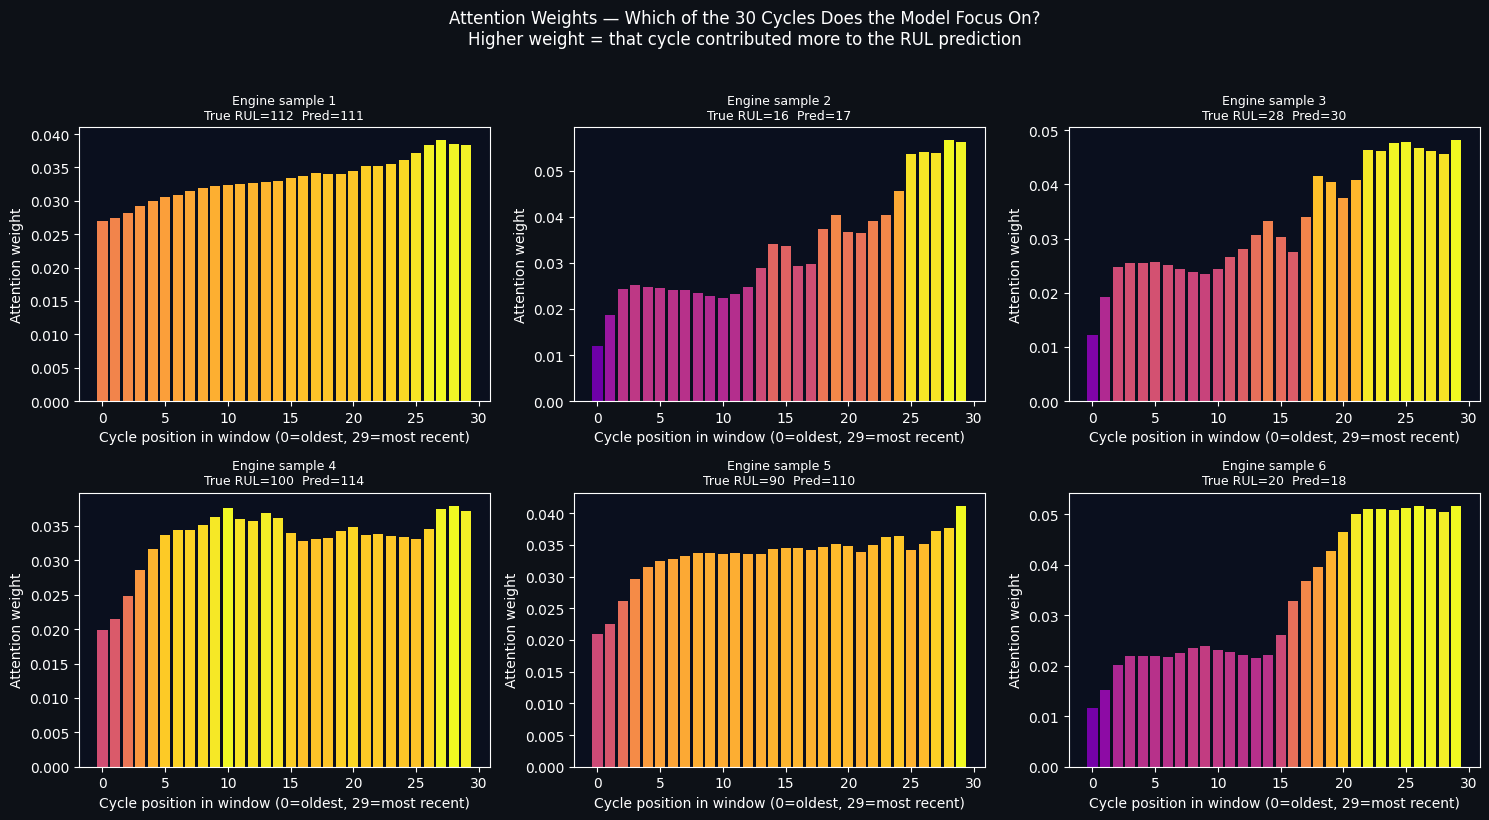

Pattern to look for: bars should be taller on the right (more recent cycles)


In [6]:
# Build a sub-model that exposes the attention weights
# We need to find the DotProductAttention layer and get its weights output
attn_layer = None
for layer in model.layers:
    if isinstance(layer, DotProductAttention):
        attn_layer = layer
        break

if attn_layer is None:
    print('No attention layer found in model — skipping attention viz')
else:
    # Find the input to the attention layer
    prev_output = attn_layer.input
    _, attn_weights_out = DotProductAttention()(prev_output)

    attn_model = keras.Model(
        inputs=model.input,
        outputs=attn_weights_out
    )

    # Get attention weights for a sample of test engines
    n_samples = 6
    sample_idx = np.linspace(0, len(X_test) - 1, n_samples, dtype=int)
    X_sample  = X_test[sample_idx]
    y_sample  = y_test[sample_idx]
    attn_w    = attn_model.predict(X_sample, verbose=0)  # [6, 30, 30]

    # Average attention across query dimension: [6, 30] — per-timestep importance
    attn_per_timestep = attn_w.mean(axis=1)  # [6, 30]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        weights = attn_per_timestep[i]
        true_rul = y_sample[i]
        pred_rul = float(model.predict(X_sample[i:i+1], verbose=0)[0][0])

        color_map = plt.cm.plasma(weights / weights.max())
        ax.bar(range(30), weights, color=color_map)
        ax.set_title(f'Engine sample {i+1}\nTrue RUL={true_rul:.0f}  Pred={pred_rul:.0f}', fontsize=9)
        ax.set_xlabel('Cycle position in window (0=oldest, 29=most recent)')
        ax.set_ylabel('Attention weight')
        ax.set_facecolor(NAVY)

    fig.suptitle('Attention Weights — Which of the 30 Cycles Does the Model Focus On?\n'
                 'Higher weight = that cycle contributed more to the RUL prediction',
                 fontsize=12, y=1.02)
    fig.patch.set_facecolor('#0d1117')
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'attention_weights.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Pattern to look for: bars should be taller on the right (more recent cycles)')

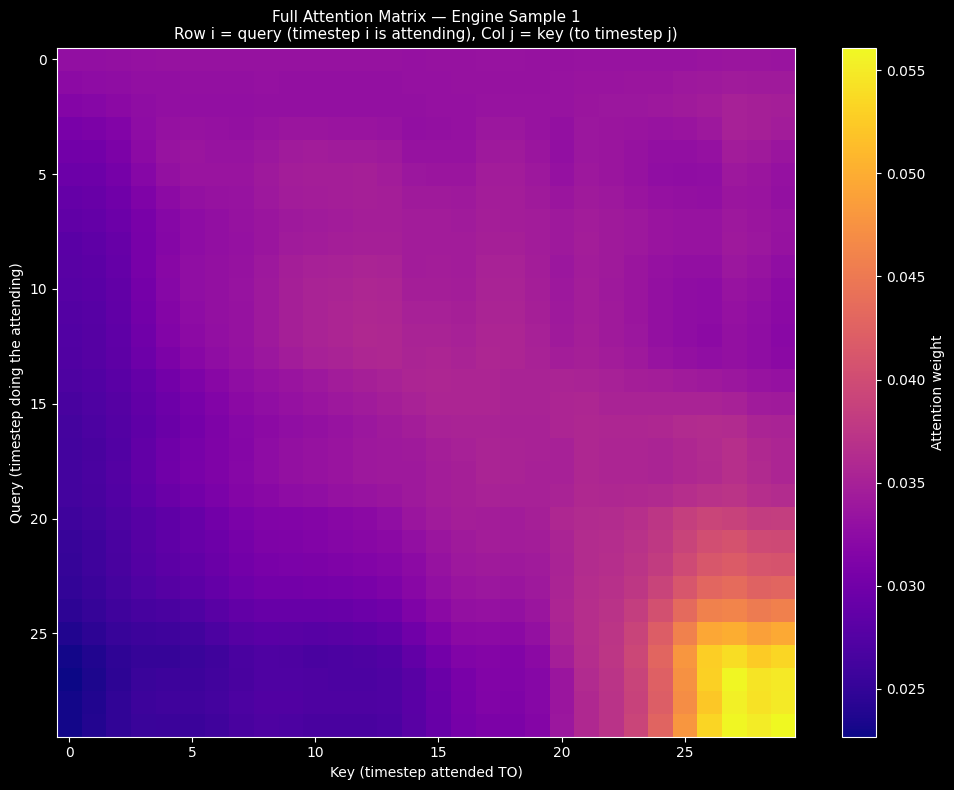

In [7]:
# ── Attention heatmap (single engine) ─────────────────────────────────────
# Full [30, 30] attention matrix — rows=query timestep, cols=key timestep
if attn_layer is not None:
    fig, ax = plt.subplots(figsize=(10, 8))
    hm_data = attn_w[0]  # First sample engine, [30, 30]
    im = ax.imshow(hm_data, cmap='plasma', aspect='auto')
    plt.colorbar(im, ax=ax, label='Attention weight')
    ax.set_title('Full Attention Matrix — Engine Sample 1\n'
                 'Row i = query (timestep i is attending), Col j = key (to timestep j)',
                 fontsize=11)
    ax.set_xlabel('Key (timestep attended TO)')
    ax.set_ylabel('Query (timestep doing the attending)')
    plt.tight_layout()
    plt.savefig(PROC_DIR / 'attention_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

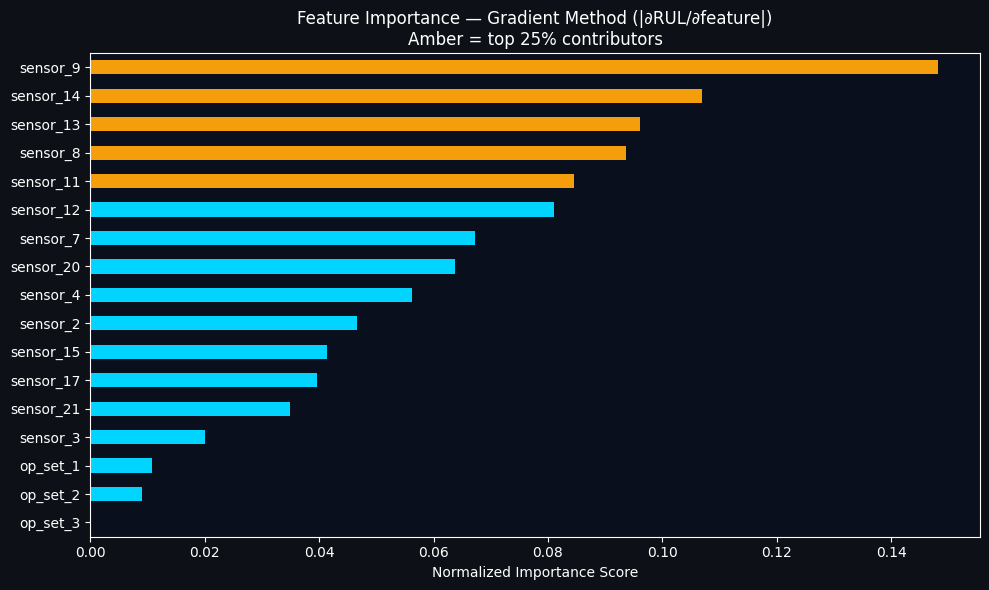

Top 5 features:
sensor_9     0.148107
sensor_14    0.106847
sensor_13    0.096161
sensor_8     0.093701
sensor_11    0.084493
dtype: float32


In [8]:
# ── Gradient-based feature importance ─────────────────────────────────────
# Same principle as backpropagation (Block 1): measure how much output changes
# with respect to each input feature — |∂RUL/∂x_i| averaged over test samples
X_sample_tf = tf.constant(X_test[:100], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(X_sample_tf)
    preds = model(X_sample_tf, training=False)

grads      = tape.gradient(preds, X_sample_tf).numpy()  # [100, 30, 17]
importance = np.abs(grads).mean(axis=(0, 1))            # [17]
importance = importance / importance.sum()

imp_series = pd.Series(importance, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
hi_thresh = imp_series.quantile(0.75)
colors    = [AMBER if v >= hi_thresh else CYAN for v in imp_series]
imp_series.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance — Gradient Method (|∂RUL/∂feature|)\n'
             'Amber = top 25% contributors', fontsize=12)
ax.set_xlabel('Normalized Importance Score')
ax.set_facecolor(NAVY)
fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.savefig(PROC_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(imp_series.nlargest(5))

In [9]:
# ── Save metrics.json for backend /model-performance endpoint ─────────────
metrics = {
    'rmse':            round(rmse, 2),
    'mae':             round(mae, 2),
    'nasa_score':      round(score, 1),
    'pct_within_10':   round(pct_within_10, 1),
    'pct_within_25':   round(pct_within_25, 1),
    'feature_importance': {
        feat: round(float(val), 4) for feat, val in imp_series.items()
    }
}

with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved backend/model/metrics.json')
print(json.dumps(metrics, indent=2))

Saved backend/model/metrics.json
{
  "rmse": 14.52,
  "mae": 10.33,
  "nasa_score": 603.4,
  "pct_within_10": 59.0,
  "pct_within_25": 92.0,
  "feature_importance": {
    "op_set_3": 0.0,
    "op_set_2": 0.0091,
    "op_set_1": 0.0108,
    "sensor_3": 0.0201,
    "sensor_21": 0.0349,
    "sensor_17": 0.0397,
    "sensor_15": 0.0413,
    "sensor_2": 0.0466,
    "sensor_4": 0.0562,
    "sensor_20": 0.0637,
    "sensor_7": 0.0673,
    "sensor_12": 0.081,
    "sensor_11": 0.0845,
    "sensor_8": 0.0937,
    "sensor_13": 0.0962,
    "sensor_14": 0.1068,
    "sensor_9": 0.1481
  }
}


## Generate Demo Data JSON

Pre-record engine sequences for the frontend Simulate button.  
These files are what the demo runs on — the live model is NOT called during the demo.

In [10]:
DEMO_DIR = Path('../frontend/src/public/demo-data')
DEMO_DIR.mkdir(parents=True, exist_ok=True)

meta_loaded = joblib.load(MODEL_DIR / 'scaler.pkl')
scaler      = meta_loaded['scaler']
feat_cols   = meta_loaded['feature_cols']
SEQ_LEN     = meta_loaded['sequence_length']
RUL_CAP     = meta_loaded['rul_cap']

# Re-load raw data to find engines at specific degradation stages
import pandas as pd
COLUMNS = (
    ['engine_id', 'cycle', 'op_set_1', 'op_set_2', 'op_set_3'] +
    [f'sensor_{i}' for i in range(1, 22)]
)
train_raw = pd.read_csv('../data/raw/train_FD001.txt',
                         sep=r'\s+', header=None, names=COLUMNS)

def compute_rul(df, cap):
    max_c = df.groupby('engine_id')['cycle'].max().rename('max_cycle')
    df = df.join(max_c, on='engine_id')
    df['rul'] = (df['max_cycle'] - df['cycle']).clip(upper=cap)
    return df.drop(columns='max_cycle')

train_raw = compute_rul(train_raw, RUL_CAP)

def engine_to_json(engine_id, df, scaler, feat_cols, n_cycles_from_end=80):
    """Export last n cycles of an engine as demo JSON with pre-computed RUL."""
    eng = df[df['engine_id'] == engine_id].copy()
    eng[feat_cols] = scaler.transform(eng[feat_cols])
    eng = eng.tail(n_cycles_from_end)

    records = []
    for _, row in eng.iterrows():
        sensor_vals = [round(float(v), 6) for v in row[feat_cols].values]
        records.append({
            'cycle':   int(row['cycle']),
            'sensors': sensor_vals,
            'rul':     round(float(row['rul']), 1)
        })
    return records

# Find engines at different degradation stages
max_ruls = train_raw.groupby('engine_id')['rul'].max()
healthy_id   = max_ruls[max_ruls > 200].index[0]   # high max RUL
degrading_id = max_ruls[(max_ruls > 80) & (max_ruls < 130)].index[0]
critical_id  = max_ruls[max_ruls < 60].index[0]

print(f'Healthy engine:   {healthy_id}  (max RUL={max_ruls[healthy_id]:.0f})')
print(f'Degrading engine: {degrading_id}  (max RUL={max_ruls[degrading_id]:.0f})')
print(f'Critical engine:  {critical_id}  (max RUL={max_ruls[critical_id]:.0f})')

for scenario, eng_id, n in [
    ('healthy',   healthy_id,   60),
    ('degrading', degrading_id, 80),  # RUL drops 200→0 across 80 cycles
    ('critical',  critical_id,  40),
]:
    records = engine_to_json(eng_id, train_raw, scaler, feat_cols, n_cycles_from_end=n)
    out_path = DEMO_DIR / f'engine_{scenario}.json'
    with open(out_path, 'w') as f:
        json.dump(records, f, indent=2)
    print(f'Saved {out_path}  ({len(records)} cycles)')

/opt/anaconda3/envs/dl_project/lib/python3.11/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


IndexError: index 0 is out of bounds for axis 0 with size 0